# Convolutional Neural Network implementation from scratch

### Imports

Loads the core libraries needed for the whole notebook — **numpy** for the vectorized math behind the model, **matplotlib** for visualization, and **PneumoniaMNIST** from the **medmnist** library as a real-data source.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from medmnist import PneumoniaMNIST

### Loading Data

Loads real pediatric chest X-ray images using MedMNIST's official predefined train/test split, rather than generating a random split

In [3]:
train_dataset = PneumoniaMNIST(split='train', download=True)
test_dataset = PneumoniaMNIST(split='test', download=True)

X_train_raw = train_dataset.imgs   # (N, 28, 28), uint8
y_train = train_dataset.labels.astype(float)  # 1 = pneumonia, 0 = normal
X_test_raw = test_dataset.imgs
y_test = test_dataset.labels.astype(float)

print(f"Training examples: {X_train_raw.shape[0]}, Test examples: {X_test_raw.shape[0]}")

100%|██████████| 4.17M/4.17M [00:05<00:00, 806kB/s] 


Training examples: 4708, Test examples: 624


### Preprocessing Images

Adds an explicit channel dimension to the grayscale images and normalizes pixel values from the raw 0–255 range down to 0–1.

In [4]:
X_train = (X_train_raw[..., np.newaxis] / 255.0).astype(float)  # (N, 28, 28, 1)
X_test = (X_test_raw[..., np.newaxis] / 255.0).astype(float)

y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

print(f"Image shape: {X_train.shape[1:]}")

Image shape: (28, 28, 1)


### Visualization

Displays a grid of real sample X-rays labeled by their true diagnosis, to inspect the actual data before training.

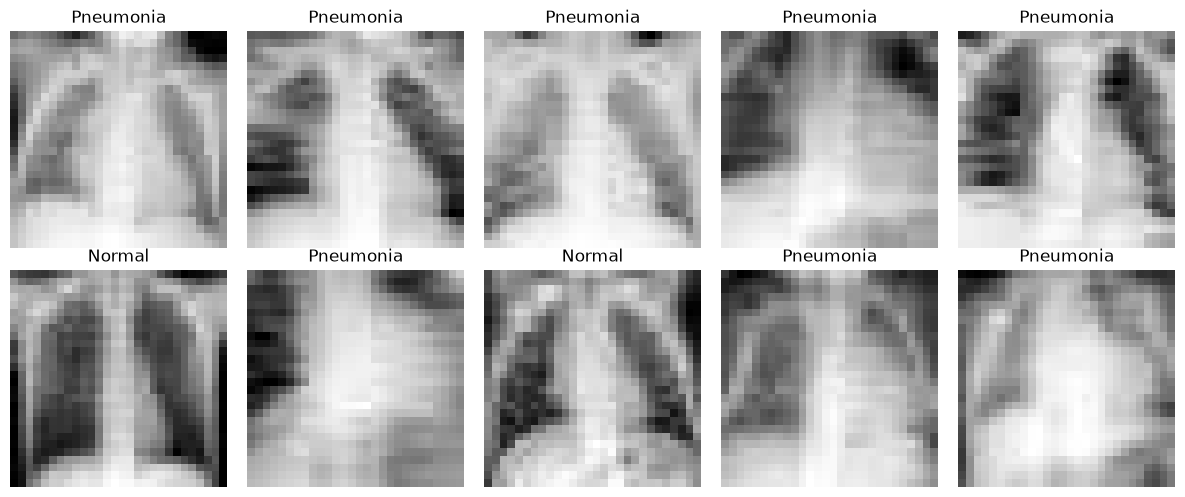

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].squeeze(), cmap='gray')
    ax.set_title('Pneumonia' if y_train[i, 0] == 1 else 'Normal')
    ax.axis('off')
plt.tight_layout()
plt.show()

### CNN Class

Implements a convolutional neural network from scratch: a 3×3 convolutional filter slides across the image (via **im2col**, which reframes convolution as a single matrix multiplication for speed) to detect local patterns, followed by max pooling to shrink the result, then a fully-connected hidden layer and sigmoid output for binary classification. **backward** implements manual backpropagation through every layer, including the convolution itself.

In [ ]:
class CNN:
    def __init__(self, input_shape=(28, 28, 1), num_filters=8, filter_size=3,
                 hidden_dim=32, learning_rate=0.05):
        self.learning_rate = learning_rate
        h, w, c = input_shape
        rng = np.random.RandomState(2)

        self.filters = rng.randn(num_filters, filter_size, filter_size, c) * np.sqrt(2 / (filter_size*filter_size*c))
        self.conv_bias = np.zeros(num_filters)
        self.pad = filter_size // 2

        pooled_h, pooled_w = h // 2, w // 2
        flat_dim = pooled_h * pooled_w * num_filters

        self.W1 = rng.randn(flat_dim, hidden_dim) * np.sqrt(2 / flat_dim)
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = rng.randn(hidden_dim, 1) * np.sqrt(2 / hidden_dim)
        self.b2 = np.zeros((1, 1))

    def im2col(self, X, fh, fw, pad):
        m, h, w, c = X.shape
        X_padded = np.pad(X, ((0,0),(pad,pad),(pad,pad),(0,0)))
        cols = np.zeros((m, h, w, fh, fw, c))
        for i in range(h):
            for j in range(w):
                cols[:, i, j] = X_padded[:, i:i+fh, j:j+fw, :]
        return cols

    def conv_forward(self, X):
        self.X = X
        m, h, w, c = X.shape
        n_filters, fh, fw, _ = self.filters.shape
        cols = self.im2col(X, fh, fw, self.pad)
        self.cols = cols
        filters_flat = self.filters.reshape(n_filters, -1)
        cols_flat = cols.reshape(m, h, w, -1)
        out = np.tensordot(cols_flat, filters_flat, axes=([3], [1])) + self.conv_bias
        self.conv_out = out
        return out

    def relu(self, z):
        return np.maximum(0, z)

    def relu_derivative(self, z):
        return (z > 0).astype(float)

    def maxpool_forward(self, X, size=2, stride=2):
        m, h, w, c = X.shape
        out_h, out_w = h // stride, w // stride
        out = np.zeros((m, out_h, out_w, c))
        self.pool_mask = np.zeros_like(X, dtype=bool)
        for i in range(out_h):
            for j in range(out_w):
                region = X[:, i*stride:i*stride+size, j*stride:j*stride+size, :]
                m_val = np.max(region, axis=(1, 2), keepdims=True)
                out[:, i, j, :] = m_val[:, 0, 0, :]
                self.pool_mask[:, i*stride:i*stride+size, j*stride:j*stride+size, :] |= (region == m_val)
        return out

    def maxpool_backward(self, dout, size=2, stride=2):
        m, out_h, out_w, c = dout.shape
        dX = np.zeros_like(self.pool_mask, dtype=float)
        for i in range(out_h):
            for j in range(out_w):
                region_mask = self.pool_mask[:, i*stride:i*stride+size, j*stride:j*stride+size, :]
                d = dout[:, i, j, :][:, None, None, :]
                dX[:, i*stride:i*stride+size, j*stride:j*stride+size, :] += region_mask * d
        return dX

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        self.conv_z = self.conv_forward(X)
        self.conv_a = self.relu(self.conv_z)
        self.pool_a = self.maxpool_forward(self.conv_a)

        m = X.shape[0]
        self.flat = self.pool_a.reshape(m, -1)
        self.z1 = self.flat @ self.W1 + self.b1
        self.a1 = self.relu(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def compute_loss(self, y_pred, y_true):
        m = y_true.shape[0]
        eps = 1e-8
        return -(1 / m) * np.sum(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))

    def backward(self, X, y_true):
        m = X.shape[0]

        dz2 = self.a2 - y_true
        dW2 = (1 / m) * self.a1.T @ dz2
        db2 = (1 / m) * np.sum(dz2, axis=0, keepdims=True)

        da1 = dz2 @ self.W2.T
        dz1 = da1 * self.relu_derivative(self.z1)
        dW1 = (1 / m) * self.flat.T @ dz1
        db1 = (1 / m) * np.sum(dz1, axis=0, keepdims=True)

        dflat = dz1 @ self.W1.T
        dpool = dflat.reshape(self.pool_a.shape)
        dconv_a = self.maxpool_backward(dpool)
        dconv_z = dconv_a * self.relu_derivative(self.conv_z)

        n_filters, fh, fw, c = self.filters.shape
        cols_flat = self.cols.reshape(m, X.shape[1], X.shape[2], -1)
        dfilters = np.tensordot(dconv_z, cols_flat, axes=([0, 1, 2], [0, 1, 2])).reshape(self.filters.shape)
        dconv_bias = np.sum(dconv_z, axis=(0, 1, 2))

        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1
        self.filters -= self.learning_rate * dfilters
        self.conv_bias -= self.learning_rate * dconv_bias

    def fit(self, X, y, epochs=200):
        losses = []
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = self.compute_loss(y_pred, y)
            losses.append(loss)
            self.backward(X, y)
            print(f"Epoch {epoch}: Loss {loss:.4f}")
        return losses

    def predict(self, X):
        return (self.forward(X) >= 0.5).astype(int)

### Training Model

Prints the real class balance and majority-class baseline first — an important sanity check on imbalanced real-world medical data, then trains the from-scratch CNN for 200 epochs on the real training set.


In [17]:
print(f"Fraction pneumonia in train: {y_train.mean():.3f}")
print(f"Majority-class baseline: {max(y_train.mean(), 1 - y_train.mean())*100:.2f}%")

cnn = CNN(input_shape=(28, 28, 1), num_filters=8, filter_size=3, hidden_dim=32, learning_rate=0.005)
losses = cnn.fit(X_train, y_train, epochs=200)

train_predictions = cnn.predict(X_train)
test_predictions = cnn.predict(X_test)

train_accuracy = np.mean(train_predictions == y_train) * 100
test_accuracy = np.mean(test_predictions == y_test) * 100

print(f"Train accuracy: {train_accuracy:.2f}%")
print(f"Test accuracy: {test_accuracy:.2f}%")

Fraction pneumonia in train: 0.742
Majority-class baseline: 74.21%
Epoch 0: Loss 0.7018
Epoch 1: Loss 1.9130
Epoch 2: Loss 1.1521
Epoch 3: Loss 0.5651
Epoch 4: Loss 0.5642
Epoch 5: Loss 0.6047
Epoch 6: Loss 0.8194
Epoch 7: Loss 0.6926
Epoch 8: Loss 0.6922
Epoch 9: Loss 0.6917
Epoch 10: Loss 0.6913
Epoch 11: Loss 0.6909
Epoch 12: Loss 0.6905
Epoch 13: Loss 0.6900
Epoch 14: Loss 0.6896
Epoch 15: Loss 0.6892
Epoch 16: Loss 0.6887
Epoch 17: Loss 0.6883
Epoch 18: Loss 0.6878
Epoch 19: Loss 0.6873
Epoch 20: Loss 0.6869
Epoch 21: Loss 0.6864
Epoch 22: Loss 0.6860
Epoch 23: Loss 0.6855
Epoch 24: Loss 0.6850
Epoch 25: Loss 0.6846
Epoch 26: Loss 0.6841
Epoch 27: Loss 0.6837
Epoch 28: Loss 0.6832
Epoch 29: Loss 0.6828
Epoch 30: Loss 0.6823
Epoch 31: Loss 0.6819
Epoch 32: Loss 0.6814
Epoch 33: Loss 0.6810
Epoch 34: Loss 0.6807
Epoch 35: Loss 0.6801
Epoch 36: Loss 0.6799
Epoch 37: Loss 0.6794
Epoch 38: Loss 0.6788
Epoch 39: Loss 0.6785
Epoch 40: Loss 0.6781
Epoch 41: Loss 0.6775
Epoch 42: Loss 0.67

Training set is 74.2% pneumonia (baseline: 74.21%). The loss curve shows an initial rough patch (a spike, then a long plateau near the baseline-equivalent loss through roughly epoch 45) before breaking through and steadily declining to 0.1981. 

Final: **92.57% train accuracy**, **83.33% test accuracy**.

### Visualizing the Loss Curve

Plots the loss value recorded at every one of the 200 training epochs.

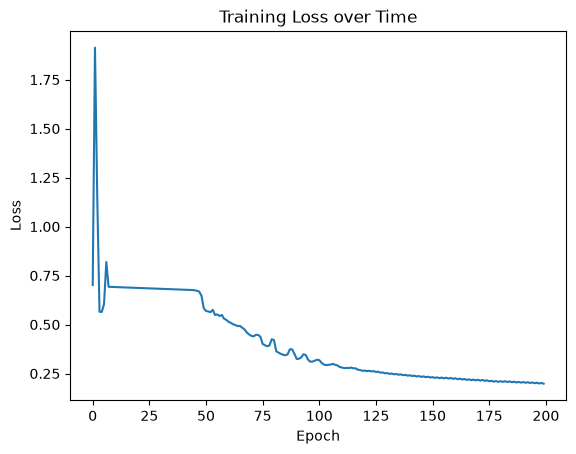

In [18]:
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Time')
plt.show()

A rocky start, an extended plateau, then a clear breakthrough into steady improvement.

### PyTorch Validation

Fits an equivalent PyTorch CNN — same architecture, same loss function, same plain SGD optimizer, same learning rate, explicitly matched Kaiming/He weight initialization, and the same 200-epoch training budget as the from-scratch version as an independent correctness check.

In [19]:
import torch
import torch.nn as nn

torch.manual_seed(2)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

torch_cnn = nn.Sequential(
    nn.Conv2d(1, 8, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(14 * 14 * 8, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
    nn.Sigmoid()
)

# match the from-scratch class's He initialization explicitly, rather than
# relying on PyTorch's different default init and a different RNG sequence
def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        nn.init.zeros_(m.bias)

torch_cnn.apply(init_weights)

criterion = nn.BCELoss()
optimizer = torch.optim.SGD(torch_cnn.parameters(), lr=0.005)

for epoch in range(200):
    optimizer.zero_grad()
    outputs = torch_cnn(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch}: Loss {loss.item():.4f}")

with torch.no_grad():
    torch_test_preds = (torch_cnn(X_test_tensor) >= 0.5).float()
    torch_test_accuracy = (torch_test_preds == y_test_tensor).float().mean().item() * 100

print(f"From scratch: {test_accuracy:.2f}%")
print(f"PyTorch:      {torch_test_accuracy:.2f}%")

Epoch 0: Loss 0.6384
Epoch 20: Loss 0.5617
Epoch 40: Loss 0.5296
Epoch 60: Loss 0.4997
Epoch 80: Loss 0.4721
Epoch 100: Loss 0.4462
Epoch 120: Loss 0.4221
Epoch 140: Loss 0.3999
Epoch 160: Loss 0.3800
Epoch 180: Loss 0.3620
From scratch: 83.33%
PyTorch:      74.36%


**83.33% (from scratch) vs. 74.36% (PyTorch)**, both trained under identical conditions. PyTorch's loss was still declining steadily at epoch 200 without having plateaued, suggesting it simply hadn't converged as far as the from-scratch version yet.